In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("cleaned_titanic.csv")

# Fix Pclass
df["Pclass"] = df["Pclass"].map({"1st": 1, "2nd": 2, "3rd": 3})

# Encode categoricals
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

In [ ]:
#Feature selection and split:

#Select features: Pclass, Sex, Age, Fare, SibSp, Parch
X = df[["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch"]]
#Target: Survived
y = df["Survived"]

#Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)



In [12]:
#Logistic Regression:

#Train the model
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_predictions):.2%}")
print(classification_report(y_test, lr_predictions))




Logistic Regression Accuracy: 74.19%
              precision    recall  f1-score   support

           0       0.76      0.85      0.80        95
           1       0.71      0.57      0.63        60

    accuracy                           0.74       155
   macro avg       0.73      0.71      0.72       155
weighted avg       0.74      0.74      0.74       155



Random Forest Accuracy: 73.55%
              precision    recall  f1-score   support

           0       0.78      0.80      0.79        95
           1       0.67      0.63      0.65        60

    accuracy                           0.74       155
   macro avg       0.72      0.72      0.72       155
weighted avg       0.73      0.74      0.73       155



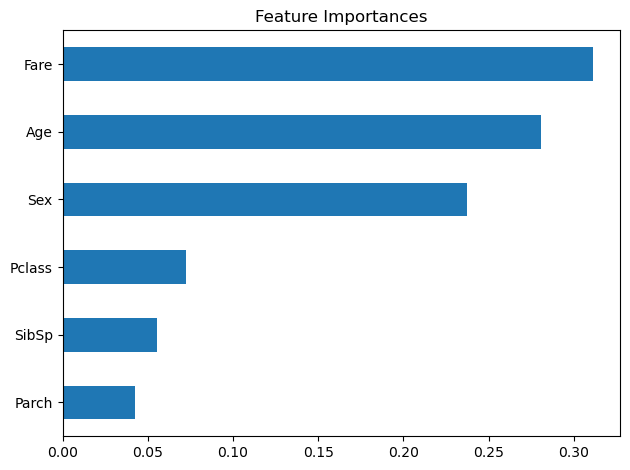

In [13]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_predictions):.2%}")
print(classification_report(y_test, rf_predictions))

# Feature importances
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh")
plt.title("Feature Importances")
plt.tight_layout()
plt.savefig("feature_importances.png")
plt.show()

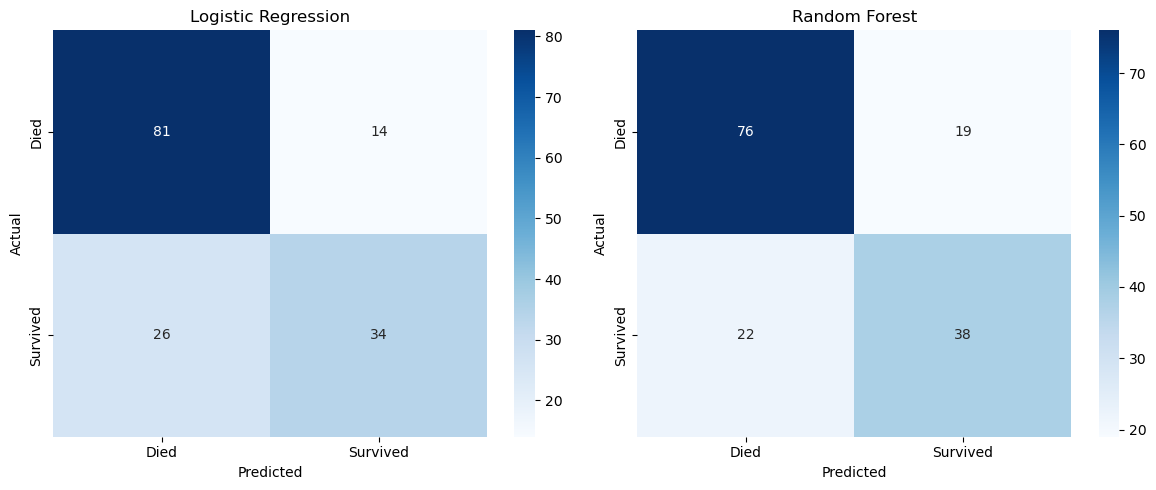

In [15]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, lr_predictions)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Died", "Survived"],
            yticklabels=["Died", "Survived"])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_rf = confusion_matrix(y_test, rf_predictions)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Died", "Survived"],
            yticklabels=["Died", "Survived"])
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png")
plt.show()